In [12]:
# autoreload
%load_ext autoreload
%autoreload 2
import os
import anndata
import pickle
import scgenome.plotting as pl

from cellmates.utils.testing import plot_diagnostics

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
data_path = '/home/vittorio.zampinetti/Cellmates/reproducibility/workflows/cnasim_makedata/results/A1_0/0/'
adata_path = os.path.join(data_path, 'anndata.h5ad')
cm_out_dir = os.path.join(data_path, 'cm_out')
diagnostics_path = os.path.join(cm_out_dir, 'em_diagnostics.pkl')

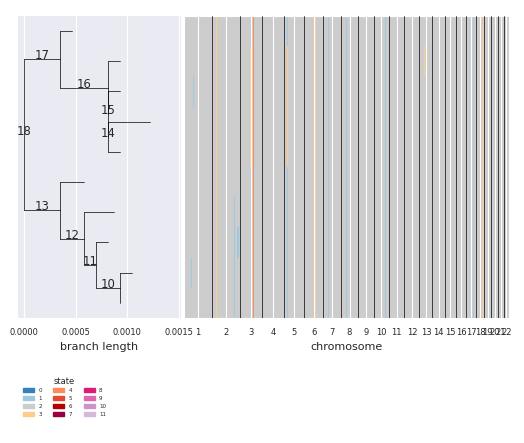

In [14]:
from cellmates.utils.tree_utils import make_gt_tree_dist
from io import StringIO
from Bio import Phylo

# plot data
adata = anndata.read_h5ad(adata_path)
bio_tree = Phylo.read(StringIO(adata.uns['cell-tree-newick']), 'newick')
# use tree from cn-derived branch lengths
cell_names = adata[~adata.obs['normal']].obs_names.tolist()
dpy_tree, gt_ctr = make_gt_tree_dist(adata, n_states=7, cell_names=cell_names)
# rename dpy tree cells
for leaf in dpy_tree.leaf_node_iter():
    leaf.taxon.label = cell_names[int(leaf.taxon.label)]
bio_tree_cn_lengths = Phylo.read(StringIO(dpy_tree.as_string(schema='newick')), 'newick')
# g = pl.plot_cell_cn_matrix_fig(adata, layer_name='copy', tree=bio_tree_cn_lengths, raw=True)
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='state', tree=bio_tree_cn_lengths)


In [4]:
# plot diagnostics
# for every cell pick their max likelihood and plot the diagnostics
diagnostics_data_pairs = pickle.load(open(diagnostics_path, 'rb'))
diagnostics_data_pairs[0, 1]

{'loglikelihoods': [None,
  3461.6299203769836,
  3691.8854670180494,
  3691.793518144103,
  3691.7929858156485,
  3691.793297738105],
 'thetas': [array([0.00028975, 0.00028975, 0.00028975]),
  array([0.00248087, 0.00033415, 0.00051477]),
  array([0.00263639, 0.00038265, 0.00058993]),
  array([0.00263675, 0.00038213, 0.00059115]),
  array([0.00263743, 0.00038209, 0.00059109]),
  array([0.00263807, 0.00038219, 0.00059132])],
 'psis': [array([ 1., 50.,  1., 50.]),
  array([ 1.00472327, 71.48115829,  1.00359819, 70.94059901]),
  array([ 1.00462023, 72.06197226,  1.00342147, 71.2803078 ]),
  array([ 1.00461652, 72.09907349,  1.00340071, 71.29495706]),
  array([ 1.00461631, 72.10043059,  1.00339961, 71.29545358]),
  array([ 1.00461628, 72.10052269,  1.00339955, 71.29548118])]}

In [5]:
import numpy as np

# pick best pairs
n_cells = adata.n_obs
final_lik_pairs = {(s,t): v['loglikelihoods'][-1] for (s,t), v in diagnostics_data_pairs.items()}
max_lik_cell = [-np.inf] * n_cells
max_cellmate = [None] * n_cells
# for each cell find the cell with which max lik is reach and track the likelihood
for (s, t), v in final_lik_pairs.items():
    if v > max_lik_cell[s]:
        max_lik_cell[s] = v
        max_cellmate[s] = t
    if v > max_lik_cell[t]:
        max_lik_cell[t] = v
        max_cellmate[t] = s

In [10]:
for s, t in enumerate(max_cellmate):
    s, t = min(s, t), max(s, t)
    g = plot_diagnostics(diagnostics_data_pairs[s,t], cm_out_dir, prefix=f'{s}-{t}')

In [11]:
diagnostics_data_pairs[0,1]

{'loglikelihoods': [None,
  3461.6299203769836,
  3691.8854670180494,
  3691.793518144103,
  3691.7929858156485,
  3691.793297738105],
 'thetas': [array([0.00028975, 0.00028975, 0.00028975]),
  array([0.00248087, 0.00033415, 0.00051477]),
  array([0.00263639, 0.00038265, 0.00058993]),
  array([0.00263675, 0.00038213, 0.00059115]),
  array([0.00263743, 0.00038209, 0.00059109]),
  array([0.00263807, 0.00038219, 0.00059132])],
 'psis': [array([ 1., 50.,  1., 50.]),
  array([ 1.00472327, 71.48115829,  1.00359819, 70.94059901]),
  array([ 1.00462023, 72.06197226,  1.00342147, 71.2803078 ]),
  array([ 1.00461652, 72.09907349,  1.00340071, 71.29495706]),
  array([ 1.00461631, 72.10043059,  1.00339961, 71.29545358]),
  array([ 1.00461628, 72.10052269,  1.00339955, 71.29548118])]}